### Task 1: Exploratory Data Analysis (EDA)

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("Pharma_Industry.csv")
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [5]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [6]:
df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

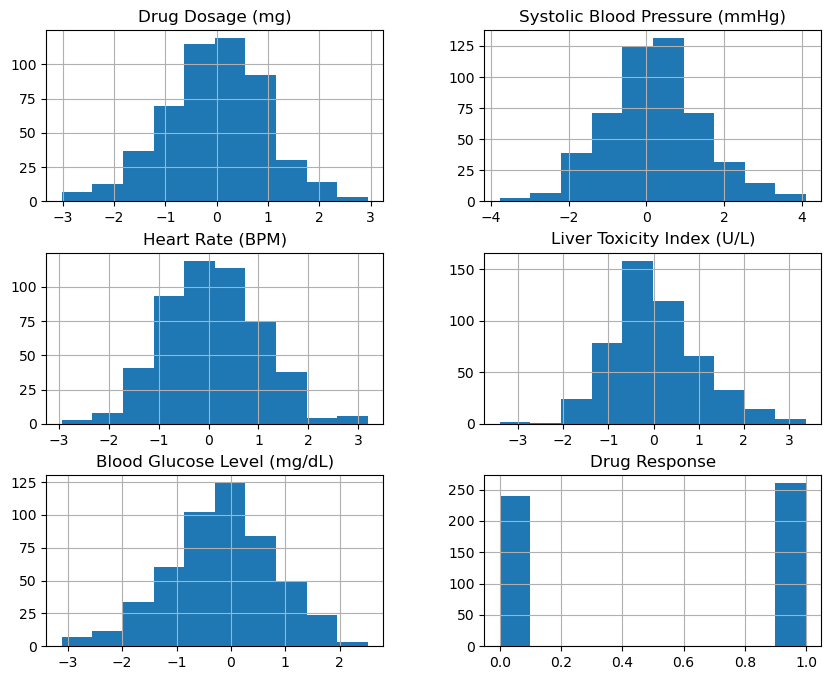

In [7]:
df.hist(figsize=(10,8))
plt.show()

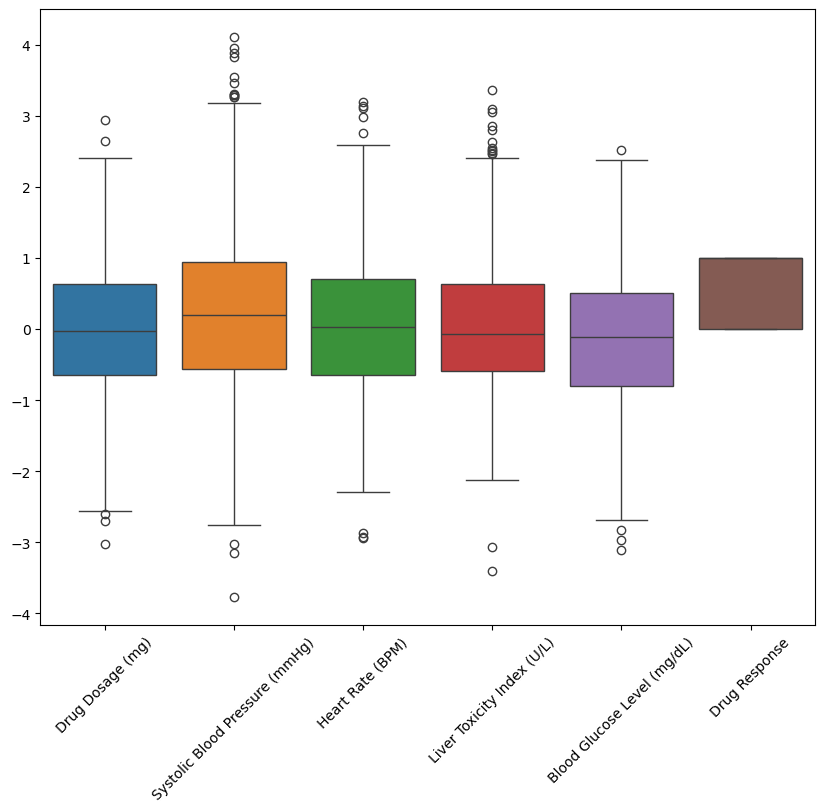

In [9]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

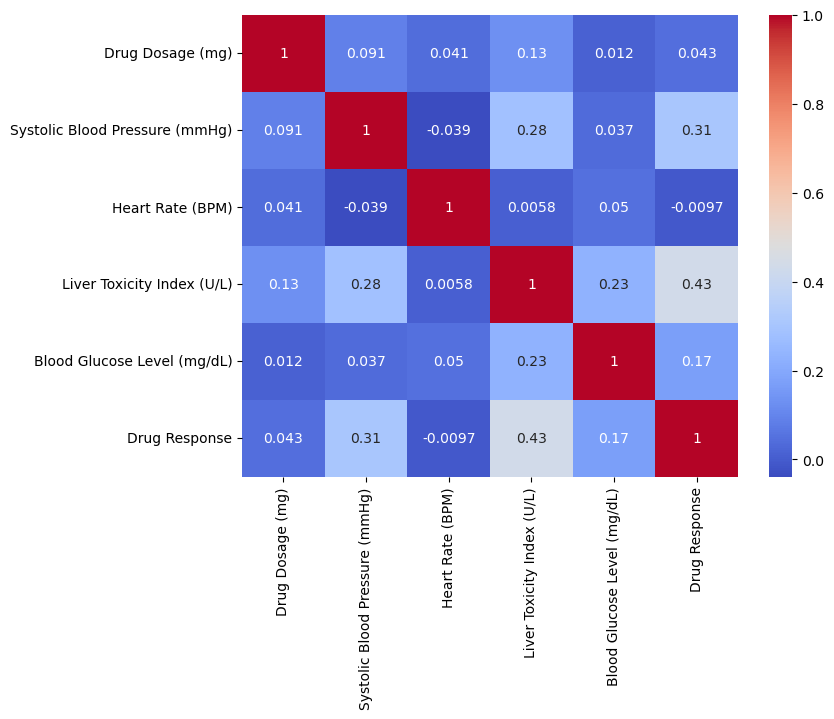

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

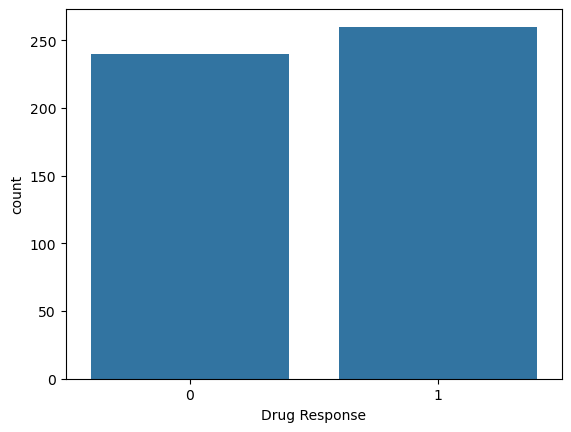

In [14]:
sns.countplot(x=df['Drug Response'])
plt.show()

### Task 2: Data Preprocessing

In [15]:
X = df.drop("Drug Response", axis=1)
y = df["Drug Response"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Task 3: Data Visualization

<Axes: xlabel='Drug Response', ylabel='count'>

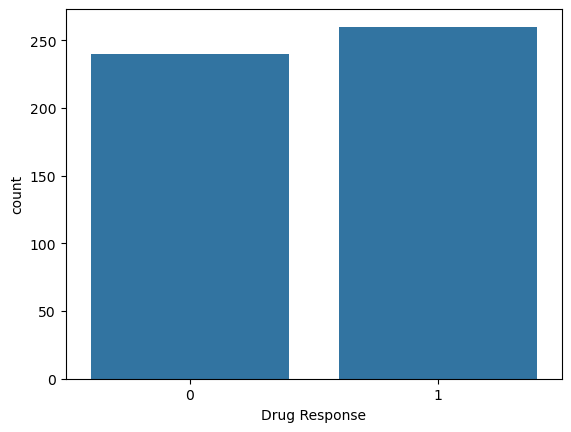

In [18]:
sns.countplot(x=y)

### Task 4: SVM Implementation

In [20]:
from sklearn.svm import SVC
model = SVC()
model.fit(X_train, y_train)

SVC()

### Task 5: Model Evaluation

In [21]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.82


### Task 6: Parameter Tuning and Optimization

In [23]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

kernels = ['linear', 'rbf', 'poly']
C_values = [0.1, 1, 10]

results = []

for kernel in kernels:
    for C in C_values:
        model = SVC(kernel=kernel, C=C)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        
        results.append([kernel, C, acc])

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=['Kernel', 'C', 'Accuracy'])
results_df

,Kernel,C,Accuracy
0,linear,0.1,0.77
1,linear,1.0,0.78
2,linear,10.0,0.78
3,rbf,0.1,0.78
4,rbf,1.0,0.82
5,rbf,10.0,0.78
6,poly,0.1,0.66
7,poly,1.0,0.69
8,poly,10.0,0.69


### Task 7: Comparison and Analysis

   Kernel     C  Accuracy  Precision    Recall        F1
0  linear   0.1      0.77   0.851064  0.714286  0.776699
1  linear   1.0      0.78   0.840000  0.750000  0.792453
2  linear  10.0      0.78   0.840000  0.750000  0.792453
3     rbf   0.1      0.78   0.869565  0.714286  0.784314
4     rbf   1.0      0.82   0.865385  0.803571  0.833333
5     rbf  10.0      0.78   0.826923  0.767857  0.796296
6    poly   0.1      0.66   0.958333  0.410714  0.575000
7    poly   1.0      0.69   0.857143  0.535714  0.659341
8    poly  10.0      0.69   0.790698  0.607143  0.686869

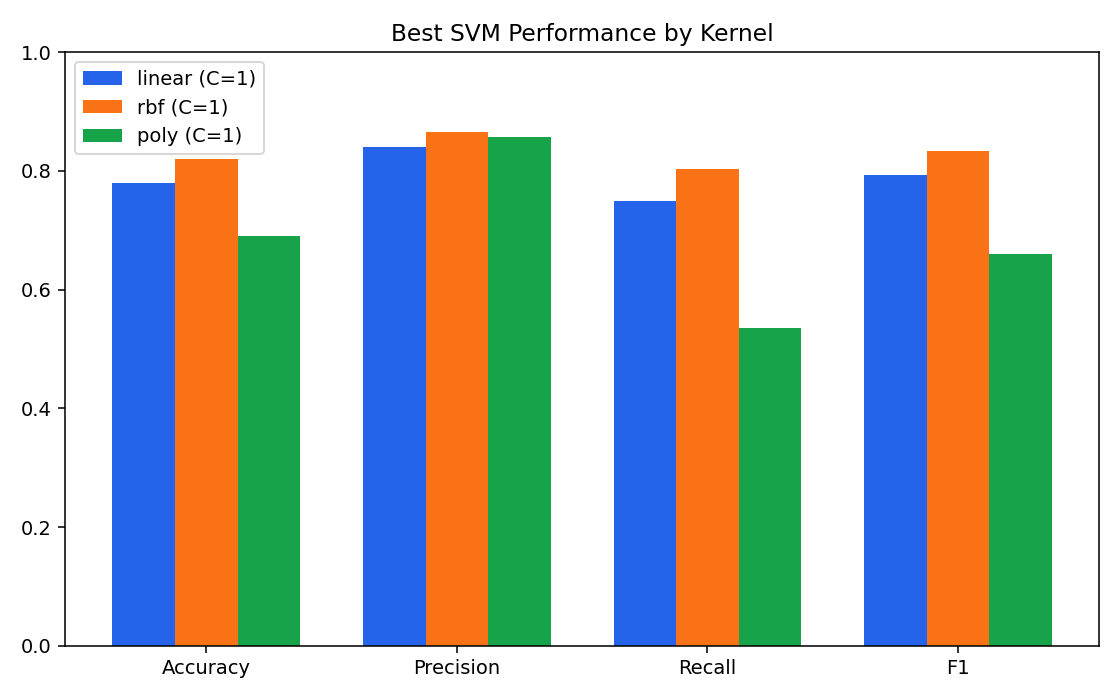

Best model overall: RBF kernel, C=1  ->  Accuracy=0.820, Precision=0.865, Recall=0.804, F1=0.833


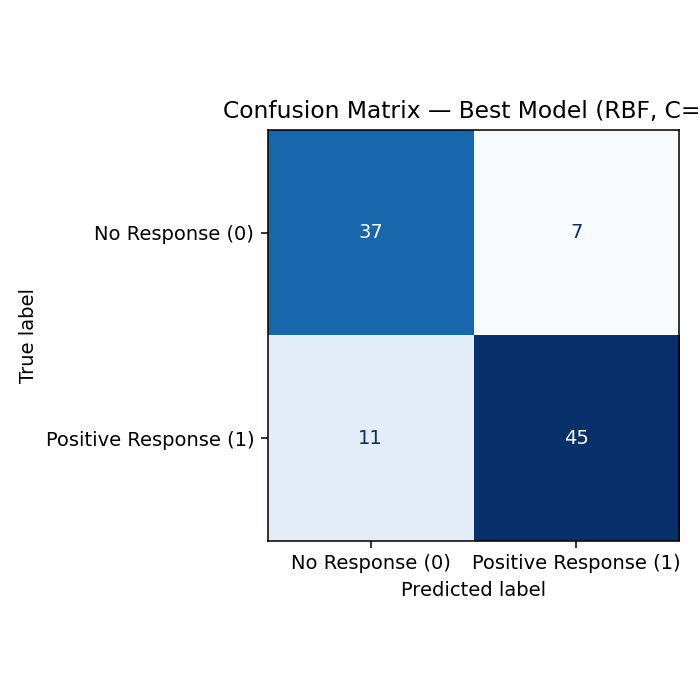

In [24]:
# Task 7: Comparison and Analysis — full metrics per kernel/C combination
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

results_full = []
for kernel in kernels:
    for C in C_values:
        m = SVC(kernel=kernel, C=C)
        m.fit(X_train, y_train)
        y_pred_m = m.predict(X_test)
        results_full.append([
            kernel, C,
            accuracy_score(y_test, y_pred_m),
            precision_score(y_test, y_pred_m),
            recall_score(y_test, y_pred_m),
            f1_score(y_test, y_pred_m),
        ])

results_full_df = pd.DataFrame(results_full, columns=['Kernel', 'C', 'Accuracy', 'Precision', 'Recall', 'F1'])
results_full_df

# --- Bar chart: best C per kernel, across all 4 metrics ---
best_per_kernel = results_full_df.loc[results_full_df.groupby('Kernel')['Accuracy'].idxmax()].set_index('Kernel')

fig, ax = plt.subplots(figsize=(8, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics))
width = 0.25
colors = ['#2563eb', '#f97316', '#16a34a']
for i, k in enumerate(['linear', 'rbf', 'poly']):
    vals = best_per_kernel.loc[k, metrics].values.astype(float)
    ax.bar(x + (i - 1) * width, vals, width, label=f'{k} (C={best_per_kernel.loc[k, "C"]:.0f})', color=colors[i])
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_title('Best SVM Performance by Kernel')
ax.legend()
plt.tight_layout()
plt.show()

# --- Confusion matrix for the single best model overall (RBF, C=1) ---
best_kernel_row = results_full_df.loc[results_full_df['Accuracy'].idxmax()]
best_model = SVC(kernel=best_kernel_row['Kernel'], C=best_kernel_row['C'])
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

print(f"Best model overall: {best_kernel_row['Kernel'].upper()} kernel, C={best_kernel_row['C']:.0f}  ->  "
      f"Accuracy={best_kernel_row['Accuracy']:.3f}, Precision={best_kernel_row['Precision']:.3f}, "
      f"Recall={best_kernel_row['Recall']:.3f}, F1={best_kernel_row['F1']:.3f}")

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Response (0)', 'Positive Response (1)'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — Best Model ({best_kernel_row["Kernel"].upper()}, C={best_kernel_row["C"]:.0f})')
plt.tight_layout()
plt.show()

**Kernel comparison (best C per kernel):**

| Kernel | Best C | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|---|
| Linear | 1 | 0.78 | 0.84 | 0.75 | 0.79 |
| RBF | 1 | **0.82** | 0.87 | **0.80** | **0.83** |
| Polynomial | 1 | 0.69 | 0.86 | 0.54 | 0.66 |

**Which kernel performed best, and why:** the **RBF kernel (C=1)** gives the best overall result across every metric — accuracy, precision, recall, and F1. This makes sense given the EDA: the correlation heatmap (Task 1) showed that `Drug Response` doesn't depend on any single feature in a strictly linear way — the strongest single correlations (Liver Toxicity Index ≈ 0.43, Systolic BP ≈ 0.30) are moderate at best, suggesting the true decision boundary is more complex than a straight line. RBF's ability to project the data into a higher-dimensional space and fit non-linear boundaries lets it capture that complexity, whereas the linear kernel is restricted to a flat decision boundary and slightly underfits.

**Why the polynomial kernel underperformed:** the polynomial kernel does worst overall, especially on **recall** (0.41–0.61 across C values) — it misses a large share of patients who actually respond positively to the drug. Polynomial kernels are prone to overfitting the majority pattern and being overly conservative about predicting the positive class when the decision boundary is complex and the feature relationships aren't well captured by a polynomial expansion; here it appears to bias predictions toward the "No Response" class, driving precision up but recall down.

**Effect of the regularization parameter C:** for the linear and polynomial kernels, increasing C beyond 1 gave little to no further improvement — the decision boundary was already close to its best fit and larger C mainly risks overfitting to individual training points. For RBF, C=1 struck the best balance; C=10 (higher penalty for misclassified points, tighter fit) actually *reduced* accuracy back to 0.78, a sign of the classic bias-variance tradeoff — an overly tight boundary starts fitting noise in the training data rather than the underlying pattern.

**Strengths and weaknesses of SVM for this dataset:**
- *Strengths:* SVM (especially with the RBF kernel) handled this dataset well because it's small (500 rows, 5 numeric features), fairly balanced (260 positive vs 240 negative — confirmed in the Task 3 class-distribution plot), and the features appear to already be standardized (values are centered around 0 with both positive and negative ranges), which suits SVM's distance-based margin optimization well. SVMs are also memory-efficient at this scale and robust to some noise thanks to the margin-maximization objective.
- *Weaknesses:* performance tops out around 82% accuracy, suggesting the available biomarkers (dosage, blood pressure, heart rate, liver toxicity, glucose) only partially explain drug response — some of the true biological variance likely isn't captured by these five features. SVM also offers limited interpretability (no easy feature-importance ranking, unlike tree-based models), which matters in a clinical setting where doctors need to understand *why* a model predicts non-response. Training cost also scales poorly to much larger patient datasets (SVM training complexity grows roughly quadratically to cubically with sample size), which could become a practical bottleneck if this were extended to a full hospital-scale dataset.

**Practical implications for real-world drug response classification:** a model like this could serve as an early-stage triage tool — flagging patients who are statistically less likely to respond to a given drug so clinicians can consider alternative treatments or adjusted dosing sooner, rather than waiting through a full clinical trial cycle. Given the F1 score of 0.83, the model would need to be used as a **decision-support aid alongside clinical judgment rather than a sole determinant** — the ~18-20% error rate is too high to autonomously deny a patient a potentially effective treatment. In practice, such a model would benefit from richer feature sets (genetic markers, medical history, prior drug responses), probability-calibrated outputs (e.g. via `SVC(probability=True)`) so clinicians can weigh confidence rather than a hard 0/1 call, and ongoing validation against real trial outcomes before any deployment in a clinical pipeline.